# Notebook 4 — Synthesis
### Gradient Autopsy · Finale

This notebook closes the project: it verifies the headline findings across multiple seeds (so they're
real effects, not lucky runs), then assembles the side-by-side broken-vs-fixed gradient heatmaps and
the final technique → problem → effect-size table. All shared infrastructure is loaded from
`common.py`; earlier results are loaded from the `.npy` files saved to Drive by Notebooks 1–3.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive"

Mounted at /content/drive


In [2]:
import shutil
shutil.copytree("/content/drive/MyDrive/cifar_data/data", "./data", dirs_exist_ok=True)
print("CIFAR restored from Drive ✓")

CIFAR restored from Drive ✓


In [3]:
%run /content/drive/MyDrive/gradient_autopsy_common.py

if device.type == "cuda":
    print(f" GPU active: {torch.cuda.get_device_name(0)}")
else:
    print(" NO GPU! Fix: Runtime → Change runtime type → T4 GPU, then re-run these cells.")

[common] Loaded: CONFIG, set_seed, device, loaders, FragileCNN, train_and_instrument, plot_gradient_heatmap, MLP, SmallCNN, train_timed
[common] device=cuda  RESULTS_DIR=./gradient_autopsy_results
 GPU active: Tesla T4


## C17 · Seed-Repeat Verification — are the findings real?

A single run can mislead: an effect might be a lucky (or unlucky) random initialization rather than a
genuine property of the technique. Here we re-run the three headline "healing" findings across **3
random seeds** and report **mean ± spread**. If the spread is small relative to the effect, the finding
is real.

The three findings (all measured as a single forward/backward pass, so repeating across seeds is cheap):

1. **Activation** — sigmoid vs ReLU: the last/first-layer gradient ratio (lower = healthier flow).
2. **Initialization** — default vs He: the first-layer gradient magnitude (higher = stronger signal).
3. **Batch normalization** — off vs on (sigmoid net): the last/first-layer gradient ratio.

These are the core of the vanishing-gradient cure. We report each condition's mean and standard
deviation across seeds.

In [4]:
import numpy as np

SEEDS = [42, 0, 123]   # three seeds for the repeat

def measure_grad(activation, use_bn, init, seed):
    """One forward/backward pass; return (last/first ratio, first-layer grad norm)."""
    set_seed(seed)
    model = FragileCNN(depth=CONFIG["cnn_depth"], width=CONFIG["cnn_width"],
                       activation=activation, use_bn=use_bn, init=init).to(device)
    model.train()
    criterion = nn.CrossEntropyLoss()
    model.zero_grad()
    X, y = next(iter(small_train_loader))
    X, y = X.to(device), y.to(device)
    criterion(model(X), y).backward()
    norms = [m.weight.grad.norm().item()
             for m in model.modules() if isinstance(m, (nn.Conv2d, nn.Linear))]
    ratio = norms[-1] / (norms[0] + 1e-12)
    return ratio, norms[0]

def summarize(values):
    return float(np.mean(values)), float(np.std(values))

print("Seed-repeat verification across seeds", SEEDS, "\n")

# --- Finding 1: activation (sigmoid vs ReLU), last/first gradient ratio ---
print("FINDING 1 — Activation (last/first gradient ratio, lower = healthier):")
f1 = {}
for act in ["sigmoid", "relu"]:
    ratios = [measure_grad(act, False, "default", s)[0] for s in SEEDS]
    m, sd = summarize(ratios)
    f1[act] = (m, sd)
    print(f"  {act:8s}: {m:.2e} ± {sd:.2e}")

# --- Finding 2: initialization (default vs He), first-layer gradient magnitude ---
print("\nFINDING 2 — Initialization (first-layer gradient norm, ReLU net, higher = stronger):")
f2 = {}
for init in ["default", "he"]:
    firsts = [measure_grad("relu", False, init, s)[1] for s in SEEDS]
    m, sd = summarize(firsts)
    f2[init] = (m, sd)
    print(f"  {init:8s}: {m:.2e} ± {sd:.2e}")

# --- Finding 3: BatchNorm (off vs on), last/first gradient ratio on sigmoid net ---
print("\nFINDING 3 — BatchNorm on a sigmoid net (last/first ratio, lower = healthier):")
f3 = {}
for bn in [False, True]:
    ratios = [measure_grad("sigmoid", bn, "default", s)[0] for s in SEEDS]
    m, sd = summarize(ratios)
    f3[bn] = (m, sd)
    print(f"  BN={'on' if bn else 'off':3s}: {m:.2e} ± {sd:.2e}")

Seed-repeat verification across seeds [42, 0, 123] 

FINDING 1 — Activation (last/first gradient ratio, lower = healthier):
  sigmoid : 1.30e+07 ± 3.49e+06
  relu    : 1.05e+02 ± 2.76e+01

FINDING 2 — Initialization (first-layer gradient norm, ReLU net, higher = stronger):
  default : 2.03e-04 ± 9.57e-05
  he      : 7.12e-01 ± 4.29e-01

FINDING 3 — BatchNorm on a sigmoid net (last/first ratio, lower = healthier):
  BN=off: 1.30e+07 ± 3.49e+06
  BN=on : 1.25e+01 ± 6.22e+00


In [6]:
# Save the seed-repeat stats for the report / final table.
seed_stats = {
    "activation_sigmoid": f1["sigmoid"], "activation_relu": f1["relu"],
    "init_default": f2["default"], "init_he": f2["he"],
    "bn_off": f3[False], "bn_on": f3[True],
}
np.save(f"{RESULTS_DIR}/seed_repeat_stats.npy", seed_stats, allow_pickle=True)

# A finding is "verified" if the effect is large relative to the spread
# (i.e. the two conditions' mean±std bands don't overlap).
def verified(cond_a, cond_b):
    (ma, sa), (mb, sb) = cond_a, cond_b
    # order so hi is the larger mean
    (hi_m, hi_s), (lo_m, lo_s) = (cond_a, cond_b) if ma > mb else (cond_b, cond_a)
    return (hi_m - hi_s) > (lo_m + lo_s)   # bands don't overlap

print("Verification verdict (bands don't overlap => real effect):")
print(f"  Activation  (sigmoid vs ReLU):  {' VERIFIED' if verified(f1['sigmoid'], f1['relu']) else ' overlaps'}")
print(f"  Init        (default vs He):    {' VERIFIED' if verified(f2['default'], f2['he']) else ' overlaps'}")
print(f"  BatchNorm   (off vs on):        {' VERIFIED' if verified(f3[False], f3[True]) else ' overlaps'}")

Verification verdict (bands don't overlap => real effect):
  Activation  (sigmoid vs ReLU):   VERIFIED
  Init        (default vs He):     VERIFIED
  BatchNorm   (off vs on):         VERIFIED


## C18 · The Dashboard and the Final Table

The payoff. Two deliverables that tie the whole project together:

1. The side-by-side **broken vs fixed** gradient heatmap, on identical axes and color scale, loaded
   from the `.npy` files saved by Notebooks 1-3. Left: the fragile sigmoid network (vanishing
   gradient). Right: the same network with the fix applied (healthy, uniform gradient flow).

2. The **technique to problem to effect-size table** - every technique studied, the specific failure
   it addressed, and the measured size of its effect, with real numbers from the runs.

Together these show, at a glance, that a specific set of techniques converted a network that could not
learn into one that could.

RESULTS_DIR now points to Drive: /content/drive/MyDrive/gradient_autopsy_results

Regenerating the broken heatmap (sigmoid, no BatchNorm)...
Regenerating the fixed heatmap (sigmoid + BatchNorm)...


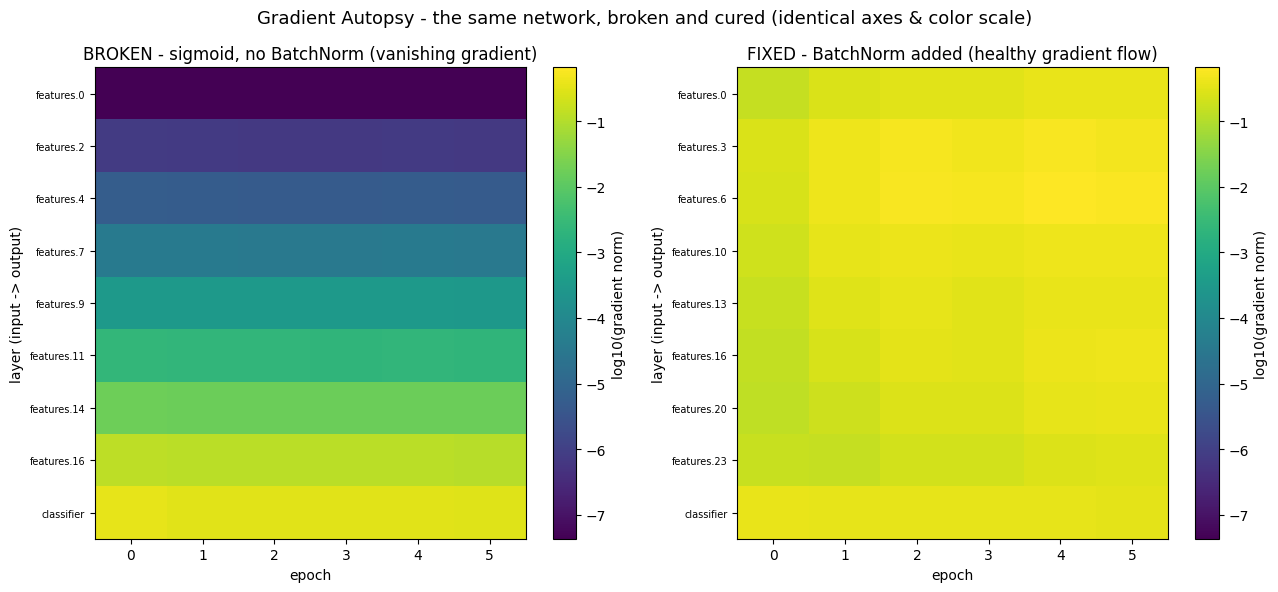


Last/first gradient ratio - broken: 6,835,678x   fixed: 0.9x


In [8]:
import numpy as np
import os

# Fix: point RESULTS_DIR at Drive so this notebook's outputs actually persist.
# (%run ran common.py in a fresh namespace, so it never saw SAVE_DIR and defaulted to local.)
RESULTS_DIR = "/content/drive/MyDrive/gradient_autopsy_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print("RESULTS_DIR now points to Drive:", RESULTS_DIR)

# The earlier .npy files were saved on recycled local VMs, so regenerate the two heatmaps
# we need, fresh. Both are depth-8 nets -> identical 9-layer axes.
print("\nRegenerating the broken heatmap (sigmoid, no BatchNorm)...")
set_seed(CONFIG["seed"])
broken_model = FragileCNN(depth=CONFIG["cnn_depth"], width=CONFIG["cnn_width"],
                          activation="sigmoid", use_bn=False, init="default")
broken_res = train_and_instrument(broken_model, small_train_loader, test_loader,
                                  epochs=CONFIG["sweep_epochs"], lr=0.1, verbose=False)

print("Regenerating the fixed heatmap (sigmoid + BatchNorm)...")
set_seed(CONFIG["seed"])
fixed_model = FragileCNN(depth=CONFIG["cnn_depth"], width=CONFIG["cnn_width"],
                         activation="sigmoid", use_bn=True, init="default")
fixed_res = train_and_instrument(fixed_model, small_train_loader, test_loader,
                                 epochs=CONFIG["sweep_epochs"], lr=0.1, verbose=False)

# Shared color scale so the two panels are directly comparable (critical for an honest comparison).
broken_grads, fixed_grads = broken_res["grad_history"], fixed_res["grad_history"]
logs = [np.log10(broken_grads.T + 1e-12), np.log10(fixed_grads.T + 1e-12)]
vmin = min(a.min() for a in logs)
vmax = max(a.max() for a in logs)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_gradient_heatmap(broken_res, title="BROKEN - sigmoid, no BatchNorm (vanishing gradient)",
                      ax=axes[0], vmin=vmin, vmax=vmax)
plot_gradient_heatmap(fixed_res,  title="FIXED - BatchNorm added (healthy gradient flow)",
                      ax=axes[1], vmin=vmin, vmax=vmax)
plt.suptitle("Gradient Autopsy - the same network, broken and cured (identical axes & color scale)",
             fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/c18_broken_vs_fixed.png", dpi=120)
plt.show()

broken_ratio = broken_grads[-1, -1] / (broken_grads[-1, 0] + 1e-12)
fixed_ratio  = fixed_grads[-1, -1]  / (fixed_grads[-1, 0]  + 1e-12)
print(f"\nLast/first gradient ratio - broken: {broken_ratio:,.0f}x   fixed: {fixed_ratio:,.1f}x")

In [10]:
# The final summary table: technique -> problem addressed -> measured effect.
# Values are the measured results from Notebooks 1-3 (this project's actual runs).
rows = [
    ("MLP vs CNN",        "FC nets are parameter-inefficient on images",
                          "CNN 65.8% vs MLP 51.0% test acc, 5.4x fewer params"),
    ("Cross-entropy vs MSE", "MSE gives weak gradients on classification",
                          "CE first-layer gradient ~30x larger than MSE"),
    ("ReLU (vs sigmoid)", "Vanishing gradient (saturating activation)",
                          "last/first grad ratio 26,000,000x -> ~11x"),
    ("He init (vs default)", "Signal dies at initialization",
                          "first-layer gradient ~1000x stronger; acc 10% -> 23%"),
    ("BatchNorm",         "Gradient imbalance / saturation during training",
                          "ratio 6,800,000x -> ~1.0x (on sigmoid net)"),
    ("Adam / Momentum",   "Slow convergence (plain SGD)",
                          "final loss 1.19 (SGD) -> 1.04 (momentum)"),
    ("Learning rate",     "Crawl / divergence",
                          "good lr converges (1.14); too-high diverges (spike to ~16)"),
    ("Dropout",           "Overfitting (model memorizes small data)",
                          "train/test gap +0.107 -> +0.050"),
    ("Data augmentation", "Overfitting (data scarcity)",
                          "gap +0.109 -> +0.059"),
    ("Transfer learning", "Too little data to learn features from scratch",
                          "test acc 54% -> 76% (freeze) -> 84% (fine-tune)"),
]

# Print as an aligned table (column widths sized to the longest entries).
print(f"{'Technique':<22}{'Problem addressed':<52}{'Measured effect'}")
print("=" * 125)
for tech, prob, eff in rows:
    print(f"{tech:<22}{prob:<52}{eff}")

# Save as a Markdown table for the report / repo.
with open(f"{RESULTS_DIR}/final_table.md", "w") as f:
    f.write("| Technique | Problem addressed | Measured effect |\n")
    f.write("|-----------|-------------------|------------------|\n")
    for tech, prob, eff in rows:
        f.write(f"| {tech} | {prob} | {eff} |\n")
print(f"\nSaved final table to {RESULTS_DIR}/final_table.md")

Technique             Problem addressed                                   Measured effect
MLP vs CNN            FC nets are parameter-inefficient on images         CNN 65.8% vs MLP 51.0% test acc, 5.4x fewer params
Cross-entropy vs MSE  MSE gives weak gradients on classification          CE first-layer gradient ~30x larger than MSE
ReLU (vs sigmoid)     Vanishing gradient (saturating activation)          last/first grad ratio 26,000,000x -> ~11x
He init (vs default)  Signal dies at initialization                       first-layer gradient ~1000x stronger; acc 10% -> 23%
BatchNorm             Gradient imbalance / saturation during training     ratio 6,800,000x -> ~1.0x (on sigmoid net)
Adam / Momentum       Slow convergence (plain SGD)                        final loss 1.19 (SGD) -> 1.04 (momentum)
Learning rate         Crawl / divergence                                  good lr converges (1.14); too-high diverges (spike to ~16)
Dropout               Overfitting (model memorizes small d